# Identity Manipulation

For Identity Manipulation, the key idea is that money launderers often create multiple identities that appear separate but share hidden attributes:

- Same phone number
- Same address
- Same device
- Same IP address
- Same employer
- Same beneficial owner
- Similar names

This is fundamentally a graph problem, not a transaction problem.

This notebook focues on:

1. Create customer identities
2. Create hidden links
3. Build an identity graph
4. Compute graph features
5. Detect suspicious clusters
6. Train a risk model

In [29]:
!pip install node2vec

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/24.4 MB ? eta -:--:--
   --- ------------------------------------ 2.1/24.4 MB 14.7 MB/s eta 0:00:02
   ------ --------------------------------- 4.2/24.4 MB 10.5 MB/s eta 0:00:02
   ---------- ----------------------------- 6.3/24.4 MB 9.9 MB/s eta 0:00:02
   ------------- -------------------------- 8.4/24.4 MB 9.8 MB/s eta 0:00:02
   --------------- ------------------------ 9.4/24.4 MB 9.8 MB/s eta 0:00:02
   --------------- ------------------------ 9.4/24.4 MB 9.8 MB/s eta 0:00:02
   --------------- ------------------------ 9.4/24.4 MB 9.8 MB/s eta 0:00:02
   ------------------ --------------------- 11.5/24.4 MB 7.0 MB/s eta 0:00:02
   ---------------------- ----------------- 13.6/24.4 MB 7.3 MB/s eta 0:00:02
   ------------------------ --------------- 14.7/24.4 MB 7.3 MB/s eta 0:00:02
   ------------------------ --------------- 14.7/24.4 MB 7.3 MB/s eta 0:00:02

  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pytensor 2.38.3 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.

[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
#!pip install Faker

In [6]:
import pandas as pd
import numpy as np

import networkx as nx

from faker import Faker

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

import matplotlib.pyplot as plt

fake = Faker()

np.random.seed(42)

In [7]:
# Generate customer dataset
n_customers = 2000

customers = []

for customer_id in range(n_customers):

    customers.append([
        customer_id,
        fake.name(),
        fake.address(),
        fake.phone_number(),
        fake.ipv4(),
        fake.company(),
        0
    ])

customers = pd.DataFrame(
    customers,
    columns=[
        "customer_id",
        "name",
        "address",
        "phone",
        "ip",
        "company",
        "suspicious"
    ]
)

customers.head()

,customer_id,name,address,phone,ip,company,suspicious
0,0,Ryan Wilson,"9515 Tammy Route Suite 077\nPort Justin, RI 32967",001-299-549-1596x32808,200.88.15.127,"Larson, Porter and Anderson",0
1,1,Shannon Webb,"68238 Christine Ramp\nKelliburgh, HI 13129",(837)955-9764x57053,157.138.171.205,"Farrell, Brown and Jones",0
2,2,Courtney Cox,"19410 Ward Lakes\nWhitestad, ME 24404",+1-503-433-3290x3530,39.218.236.192,"Rodriguez, Vega and Turner",0
3,3,Amanda Martinez,USCGC Fox\nFPO AE 08374,001-969-571-5908x54405,25.21.210.167,"Lewis, Reeves and Navarro",0
4,4,Briana Kirk,"9984 David Inlet Suite 491\nNew Adrian, PA 04511",937.789.6558x26548,159.244.245.190,Cisneros and Sons,0


In [8]:
# Create syntehtic identity rings - groups of customers sharing information
# These represent:
# - mule rings
# - shell company groups
# - synthetic identities

for ring in range(50):

    members = np.random.choice(
        customers.index,
        size=np.random.randint(3,10),
        replace=False
    )

    shared_phone = fake.phone_number()
    shared_address = fake.address()

    for idx in members:

        customers.loc[idx, "phone"] = shared_phone
        customers.loc[idx, "address"] = shared_address
        customers.loc[idx, "suspicious"] = 1

In [9]:
# Sanity check
customers["suspicious"].value_counts()

suspicious
0    1718
1     282
Name: count, dtype: int64

In [10]:
# Build identity graph with nodes:
# - Customer
# - Phone
# - Address
# - IP
# - Company
G = nx.Graph()

In [11]:
# Add customer nodes
for _, row in customers.iterrows():

    customer_node = f"C_{row.customer_id}"

    G.add_node(
        customer_node,
        node_type="customer"
    )

In [12]:
# Add attribute nodes
for _, row in customers.iterrows():

    c = f"C_{row.customer_id}"

    phone = f"P_{row.phone}"
    address = f"A_{hash(row.address)}"
    ip = f"I_{row.ip}"
    company = f"B_{row.company}"

    G.add_edge(c, phone)
    G.add_edge(c, address)
    G.add_edge(c, ip)
    G.add_edge(c, company)

In [13]:
# Graph summary
print(
    "Nodes:",
    G.number_of_nodes()
)

print(
    "Edges:",
    G.number_of_edges()
)

Nodes: 9449
Edges: 8000


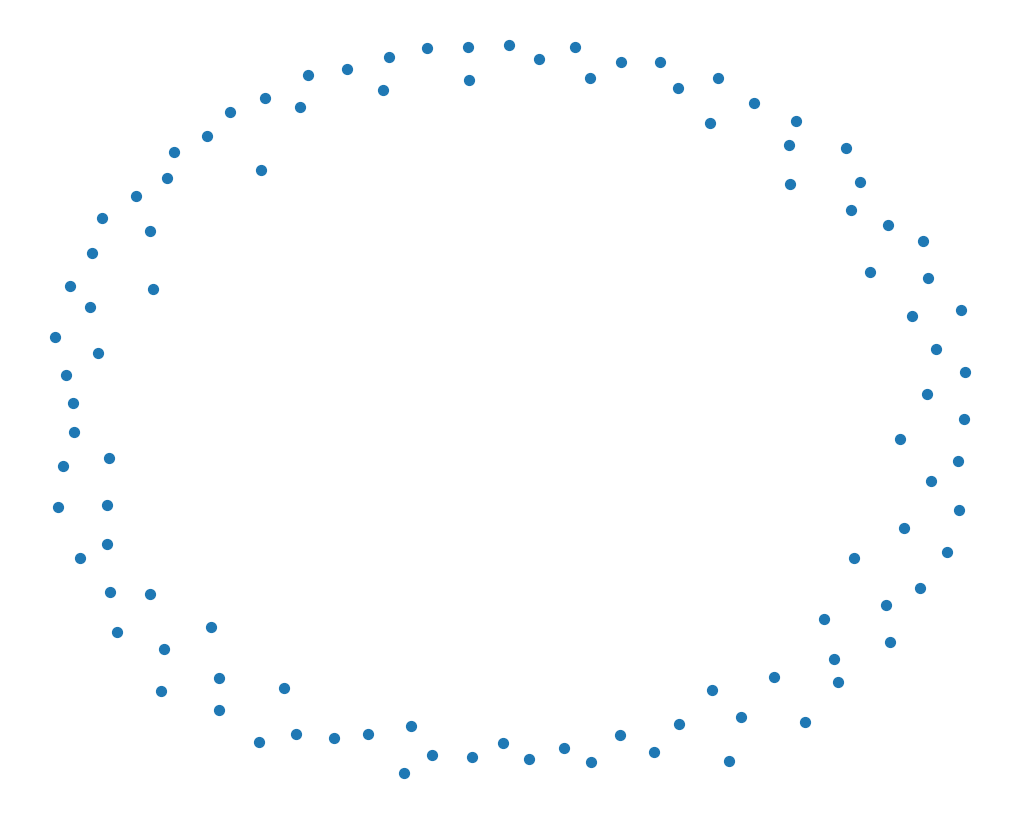

In [14]:
# Visualize small example
sample_nodes = list(G.nodes())[:100]

subgraph = G.subgraph(sample_nodes)

plt.figure(figsize=(10,8))

nx.draw(
    subgraph,
    node_size=50,
    with_labels=False
)

plt.show()

In [15]:
# Degree centrality - Shared identities create unusually connected nodes.
degree = nx.degree_centrality(G)

degree_df = pd.DataFrame(
    degree.items(),
    columns=["node","degree"]
)

degree_df.sort_values(
    "degree",
    ascending=False
).head()

,node,degree
2236,A_408327203575516456,0.000953
2235,P_372.757.8269x1028,0.000953
3159,P_469-364-5090,0.000953
3160,A_-8898101475638128962,0.000953
2405,P_993-488-0620x41173,0.000847


In [16]:
# Betweeness centrality - usefull for hidden connectors
betweenness = nx.betweenness_centrality(
    G,
    k=500
)

betweenness_df = pd.DataFrame(
    betweenness.items(),
    columns=[
        "node",
        "betweenness"
    ]
)

betweenness_df.sort_values(
    "betweenness",
    ascending=False
).head()

,node,betweenness
3726,B_Davis LLC,0.000053
1657,C_1657,0.000032
929,C_929,0.000031
1805,C_1805,0.000027
1876,C_1876,0.000027


In [17]:
# Detect communities
from networkx.algorithms.community import (
    greedy_modularity_communities
)

communities = list(
    greedy_modularity_communities(G)
)

len(communities)

1681

In [18]:
# Community sizes
community_sizes = [
    len(c)
    for c in communities
]

pd.Series(
    community_sizes
).describe()
# Large unusual communities often indicate:
# - identity farms
# - mule networks
# - shell structures

count    1681.000000
mean        5.621059
std         3.500307
min         5.000000
25%         5.000000
50%         5.000000
75%         5.000000
max        75.000000
dtype: float64

In [19]:
# Create customer-level features
features = []

for customer_id in customers.customer_id:

    node = f"C_{customer_id}"

    features.append([
        customer_id,
        degree.get(node,0),
        betweenness.get(node,0)
    ])

features = pd.DataFrame(
    features,
    columns=[
        "customer_id",
        "degree",
        "betweenness"
    ]
)

In [20]:
# Count shared attributes
shared_counts = []

for customer_id in customers.customer_id:

    node = f"C_{customer_id}"

    neighbors = list(
        G.neighbors(node)
    )

    shared = 0

    for n in neighbors:

        if G.degree(n) > 1:
            shared += 1

    shared_counts.append(shared)

features["shared_attributes"] = (
    shared_counts
)

In [21]:
# Merge labels
features = features.merge(
    customers[
        [
            "customer_id",
            "suspicious"
        ]
    ],
    on="customer_id"
)

features.head()

,customer_id,degree,betweenness,shared_attributes,suspicious
0,0,0.000423,6.351223e-07,0,0
1,1,0.000423,0.000000e+00,0,0
2,2,0.000423,0.000000e+00,0,0
3,3,0.000423,0.000000e+00,0,0
4,4,0.000423,4.242634e-07,2,1


In [22]:
# Feature inspection
features.groupby(
    "suspicious"
).mean()
# You should observe suspicious identities having:
# - higher degree
# - more shared attributes

,customer_id,degree,betweenness,shared_attributes
suspicious,,,,
0,1001.183935,0.000423,1.863430e-07,0.076834
1,989.241135,0.000423,1.710664e-06,2.067376


In [23]:
# Train ML model
X = features[
    [
        "degree",
        "betweenness",
        "shared_attributes"
    ]
]

y = features["suspicious"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

model = RandomForestClassifier(
    n_estimators=200,
    max_depth=6,
    random_state=42
)

model.fit(
    X_train,
    y_train
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",6
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_

In [24]:
# Evaluate
preds = model.predict(X_test)

print(
    classification_report(
        y_test,
        preds
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       344
           1       1.00      1.00      1.00        56

    accuracy                           1.00       400
   macro avg       1.00      1.00      1.00       400
weighted avg       1.00      1.00      1.00       400



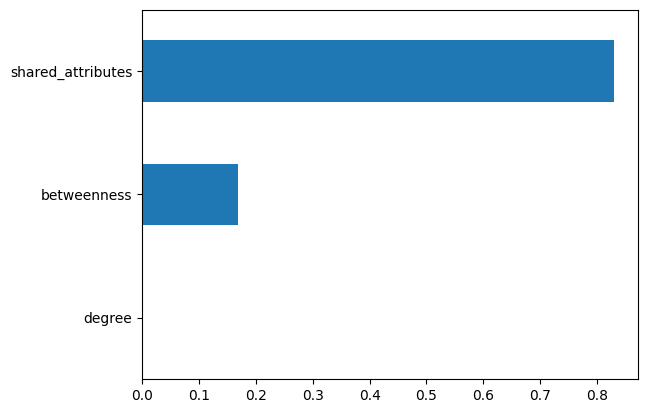

In [25]:
# Feature importance
importance = pd.Series(
    model.feature_importances_,
    index=X.columns
)

importance.sort_values().plot(
    kind="barh"
)

plt.show()

In [26]:
# Risk scoring
features["risk_score"] = (
    model.predict_proba(X)
    [:,1]
)

features.sort_values(
    "risk_score",
    ascending=False
).head(20)

,customer_id,degree,betweenness,shared_attributes,suspicious,risk_score
1984,1984,0.000423,0.000000e+00,2,1,1.0
19,19,0.000423,0.000000e+00,2,1,1.0
1967,1967,0.000423,0.000000e+00,2,1,1.0
1964,1964,0.000423,0.000000e+00,2,1,1.0
1961,1961,0.000423,0.000000e+00,2,1,1.0
1953,1953,0.000423,0.000000e+00,2,1,1.0
1949,1949,0.000423,1.270245e-06,3,1,1.0
1934,1934,0.000423,1.270245e-06,2,1,1.0
1932,1932,0.000423,1.697053e-06,2,1,1.0
1914,1914,0.000423,8.821143e-07,2,1,1.0


In [27]:
# Explain top alert
top_customer = (
    features
    .sort_values(
        "risk_score",
        ascending=False
    )
    .iloc[0]
    .customer_id
)

node = f"C_{int(top_customer)}"

list(G.neighbors(node))

['P_498.260.1176',
 'A_-2125730581479780630',
 'I_152.211.124.199',
 'B_Williams-Mitchell']

In [28]:
# Node2Vec embeddings
from node2vec import Node2Vec

node2vec = Node2Vec(
    G,
    dimensions=64,
    walk_length=20,
    num_walks=100
)

model_embeddings = node2vec.fit()
# Each customer becomes a 64-dimensional vector capturing network behavior.
# These embeddings are often fed into:
# - XGBoost
# - LightGBM
# - Graph Neural Networks
# and typically outperform hand-crafted graph features.

ModuleNotFoundError: No module named 'node2vec'

Common systems flow:
```
Customer Graph
       ↓
GraphSAGE
       ↓
Customer Embedding
       ↓
Risk Classifier
       ↓
SAR Recommendation
```

This is very close to what large financial institutions and specialized AML vendors use today for detecting:
- synthetic identities
- mule networks
- shell company structures
- beneficial ownership concealment
- organized laundering rings.